# 聚合：最小值、最大值及其间的一切


探索任何数据集的第一步通常是计算各种汇总统计量。

最常见的汇总统计量可能是均值和标准差，它们可以帮助您总结数据集中“典型”的值，但其他聚合方式也同样有用（如求和、乘积、中位数、最小值和最大值、分位数等）。

NumPy 提供了快速的内置聚合函数，用于处理数组；我们将在这里讨论并尝试其中的一些。

## 数组中值的求和

作为一个简单的例子，考虑计算数组中所有值的总和。

Python 可以使用内置的 `sum` 函数来完成这个任务。

In [1]:
import numpy as np
rng = np.random.default_rng()

In [2]:
L = rng.random(100)
sum(L)

np.float64(50.036444677781034)

语法与NumPy的`sum`函数非常相似，在最简单的情况下，结果也是相同的：

In [3]:
np.sum(L)

np.float64(50.03644467778103)

However, because it executes the operation in compiled code, NumPy's version of the operation is computed much more quickly:

In [4]:
big_array = rng.random(1000000)
%timeit sum(big_array)
%timeit np.sum(big_array)

21.8 ms ± 101 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
165 μs ± 336 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


请注意，`sum` 函数和 `np.sum` 函数并不相同，这有时会导致混淆！

特别是，它们的可选参数具有不同的含义（`sum(x, 1)` 将总和初始化为 `1`，而 `np.sum(x, 1)` 则是在轴 `1` 上求和），并且 `np.sum` 能够处理多个数组维度，正如我们将在下一节中看到的那样。

## 最小值和最大值

同样，Python 提供了内置的 `min` 和 `max` 函数，用于查找给定数组中的最小值和最大值。

In [5]:
min(big_array), max(big_array)

(np.float64(5.183072704362246e-07), np.float64(0.9999997977263602))

NumPy的相应函数具有类似的语法，并且运行速度更快。

In [6]:
np.min(big_array), np.max(big_array)

(np.float64(5.183072704362246e-07), np.float64(0.9999997977263602))

In [7]:
%timeit min(big_array)
%timeit np.min(big_array)

15.7 ms ± 148 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
151 μs ± 704 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


对于 `min`、`max`、`sum` 以及其他几个 NumPy 聚合函数，可以使用数组对象本身的方法来实现更简洁的语法：


In [8]:
print(big_array.min(), big_array.max(), big_array.sum())

5.183072704362246e-07 0.9999997977263602 500122.91373963177


尽可能确保在操作NumPy数组时使用这些聚合的NumPy版本！

### 多维聚合

一种常见的聚合操作是沿着行或列进行聚合。

假设您有一些数据存储在一个二维数组中：

In [9]:
M = rng.integers(0, 10, (3, 4))
print(M)

[[0 9 9 4]
 [9 6 9 0]
 [0 3 8 8]]


NumPy 聚合将应用于多维数组的所有元素：

In [10]:
M.sum()

np.int64(65)

聚合函数需要一个额外的参数，用于指定计算聚合值的*轴*。例如，我们可以通过指定`axis=0`来找到每一列中的最小值：

In [11]:
M.min(axis=0)

array([0, 3, 8, 0])

该函数返回四个值，分别对应四列数字。

同样，我们可以找到每一行中的最大值：

In [12]:
M.max(axis=1)

array([9, 9, 8])

这里指定轴的方式可能会让来自其他语言的用户感到困惑。

`axis` 关键字指定的是将要被 *压缩* 的数组维度，而不是返回的维度。

因此，指定 `axis=0` 意味着轴 0 将被压缩：对于二维数组，每列中的值将被聚合。

### 其他聚合函数

NumPy 提供了几种其他具有相似 API 的聚合函数。此外，大多数函数都有一个 `NaN` 安全的对应版本，该版本在计算结果时会忽略缺失值，这些缺失值由特殊的 IEEE 浮点数 `NaN` 值标记（参见 [处理缺失数据](03.04-Missing-Values.ipynb)）。

下表列出了 NumPy 中可用的一些有用的聚合函数：

|Function name    |   NaN-safe version| Description                                   |
|-----------------|-------------------|-----------------------------------------------|
| `np.sum`        | `np.nansum`       | Compute sum of elements                       |
| `np.prod`       | `np.nanprod`      | Compute product of elements                   |
| `np.mean`       | `np.nanmean`      | Compute mean of elements                      |
| `np.std`        | `np.nanstd`       | Compute standard deviation                    |
| `np.var`        | `np.nanvar`       | Compute variance                              |
| `np.min`        | `np.nanmin`       | Find minimum value                            |
| `np.max`        | `np.nanmax`       | Find maximum value                            |
| `np.argmin`     | `np.nanargmin`    | Find index of minimum value                   |
| `np.argmax`     | `np.nanargmax`    | Find index of maximum value                   |
| `np.median`     | `np.nanmedian`    | Compute median of elements                    |
| `np.percentile` | `np.nanpercentile`| Compute rank-based statistics of elements     |
| `np.any`        | N/A               | Evaluate whether any elements are true        |
| `np.all`        | N/A               | Evaluate whether all elements are true        |

您将在本书的其余部分中经常看到这些聚合体。

## 示例：美国总统的平均身高是多少？



NumPy 中可用的聚合函数可以作为一组值的汇总统计。

作为一个小例子，我们来考虑所有美国总统的身高。

这些数据存储在文件 *president_heights.csv* 中，该文件是一个以逗号分隔的标签和值列表。

In [13]:
!head -4 data/president_heights.csv

order,name,height(cm)
1,George Washington,189
2,John Adams,170
3,Thomas Jefferson,189


我们将使用Pandas包，关于这一点我们将在[第3部分](03.00-Introduction-to-Pandas.ipynb)中进行更深入的探讨，以读取文件并提取这些信息（请注意，身高以厘米为单位测量）。

In [14]:
import pandas as pd
data = pd.read_csv('data/president_heights.csv')
heights = np.array(data['height(cm)'])
print(heights)

[189 170 189 163 183 171 185 168 173 183 173 173 175 178 183 193 178 173
 174 183 183 168 170 178 182 180 183 178 182 188 175 179 183 193 182 183
 177 185 188 188 182 185 191 182]


现在我们有了这个数据数组，我们可以计算多种汇总统计信息：

In [15]:
print("Mean height:       ", heights.mean())
print("Standard deviation:", heights.std())
print("Minimum height:    ", heights.min())
print("Maximum height:    ", heights.max())

Mean height:        180.04545454545453
Standard deviation: 6.983599441335736
Minimum height:     163
Maximum height:     193


请注意，在每种情况下，聚合操作将整个数组简化为一个单一的汇总值，这为我们提供了关于数值分布的信息。

我们也可能希望计算分位数：

In [16]:
print("25th percentile:   ", np.percentile(heights, 25))
print("Median:            ", np.median(heights))
print("75th percentile:   ", np.percentile(heights, 75))

25th percentile:    174.75
Median:             182.0
75th percentile:    183.5


我们看到美国总统的中位身高为182厘米，接近六英尺。

当然，有时以可视化方式呈现这些数据更为有用，我们可以使用Matplotlib中的工具来实现这一点（我们将在[第4部分](04.00-Introduction-To-Matplotlib.ipynb)中详细讨论Matplotlib）。例如，这段代码生成了以下图表：

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

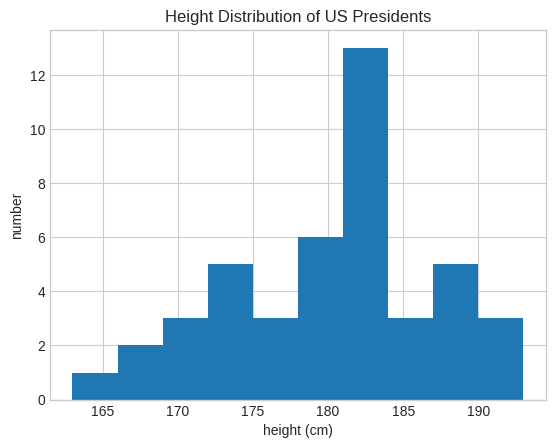

In [18]:
plt.hist(heights)
plt.title('Height Distribution of US Presidents')
plt.xlabel('height (cm)')
plt.ylabel('number');